# RSNA Pneumonia Detection — Improved Multimodal Colab Notebook

This notebook trains and compares a custom CNN, an image-only EfficientNetB0 model, and an improved EfficientNetB0 + metadata multimodal model. The updated multimodal model uses a stronger fusion branch, longer training, deeper fine-tuning, a 75/10/15 split, and validation-based threshold selection.




In [ ]:
# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2. IMPORTS, REPRODUCIBILITY AND GPU SETUP
# ============================================================
import os
import re
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydicom

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU detected:", gpus)
    except RuntimeError as error:
        print("GPU configuration warning:", error)
else:
    print("No GPU detected. In Colab, select Runtime > Change runtime type > T4 GPU.")

print("TensorFlow version:", tf.__version__)

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# ============================================================
# 4. CONFIGURATION AND AUTOMATIC DATASET LOCATION
# ============================================================
CANDIDATE_ROOTS = [
    "/content/drive/MyDrive/rsna-pneumonia-detection-challenge",
    "/content/drive/MyDrive/RSNA/rsna-pneumonia-detection-challenge",
    "/content/drive/MyDrive/RSNA Pneumonia Detection Challenge",
    "/content/drive/MyDrive",
]

def locate_rsna_dataset(candidate_roots):
    for root in candidate_roots:
        root = Path(root)
        labels_file = root / "stage_2_train_labels.csv"
        images_dir = root / "stage_2_train_images"
        if labels_file.is_file() and images_dir.is_dir():
            return root

    mydrive = Path("/content/drive/MyDrive")
    matches = list(mydrive.glob("**/stage_2_train_labels.csv"))
    for labels_file in matches:
        root = labels_file.parent
        if (root / "stage_2_train_images").is_dir():
            return root

    raise FileNotFoundError(
        "Could not locate the unzipped RSNA dataset. The folder must contain "
        "stage_2_train_labels.csv and stage_2_train_images. Edit CANDIDATE_ROOTS."
    )

RSNA_DIR = locate_rsna_dataset(CANDIDATE_ROOTS)
LABELS_CSV = RSNA_DIR / "stage_2_train_labels.csv"
IMAGE_DIR = RSNA_DIR / "stage_2_train_images"
OUTPUT_DIR = Path("/content/drive/MyDrive/rsna_pneumonia_outputs_improved")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_CUSTOM_CNN = 8
EPOCHS_IMAGE_ONLY = 10
EPOCHS_MULTIMODAL_HEAD = 20
EPOCHS_MULTIMODAL_FINETUNE = 15
FINE_TUNE_AT_FRACTION = 0.70
RUN_FINE_TUNING = True
HEAD_LEARNING_RATE = 3e-4
FINETUNE_LEARNING_RATE = 5e-6

print("RSNA dataset:", RSNA_DIR)
print("Labels CSV:", LABELS_CSV)
print("Images directory:", IMAGE_DIR)
print("Outputs:", OUTPUT_DIR)


RSNA dataset: /content/drive/MyDrive
Labels CSV: /content/drive/MyDrive/stage_2_train_labels.csv
Images directory: /content/drive/MyDrive/stage_2_train_images
Outputs: /content/drive/MyDrive/rsna_pneumonia_outputs_improved


In [ ]:
# ============================================================
# 5. LOAD AND PREPARE CLASSIFICATION LABELS
# ============================================================
labels_raw = pd.read_csv(LABELS_CSV)
labels_raw.columns = [column.strip() for column in labels_raw.columns]

required_columns = {"patientId", "Target"}
missing_columns = required_columns.difference(labels_raw.columns)
if missing_columns:
    raise ValueError(f"Missing required label columns: {sorted(missing_columns)}")

# A pneumonia image may have multiple bounding-box rows.
# For binary classification, keep one row per patient and use the maximum target.
labels_df = (
    labels_raw.groupby("patientId", as_index=False)["Target"]
    .max()
    .rename(columns={"patientId": "PatientId", "Target": "label"})
)

labels_df["filepath"] = labels_df["PatientId"].map(
    lambda patient_id: str(IMAGE_DIR / f"{patient_id}.dcm")
)

existing_mask = labels_df["filepath"].map(os.path.isfile)
missing_count = int((~existing_mask).sum())
if missing_count:
    print(f"Warning: excluding {missing_count} label rows with missing DICOM files.")

labels_df = labels_df.loc[existing_mask].reset_index(drop=True)
labels_df["label"] = labels_df["label"].astype(np.float32)

if labels_df.empty:
    raise RuntimeError("No matching DICOM images were found.")

print(labels_df.head())
print("\nTotal unique images:", len(labels_df))
print("Class counts:")
print(labels_df["label"].value_counts().sort_index())

                              PatientId  label  \
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    0.0   
1  000924cf-0f8d-42bd-9158-1af53881a557    0.0   
2  000db696-cf54-4385-b10b-6b16fbb3f985    1.0   
3  000fe35a-2649-43d4-b027-e67796d412e0    1.0   
4  001031d9-f904-4a23-b3e5-2c088acd19c6    1.0   

                                            filepath  
0  /content/drive/MyDrive/stage_2_train_images/00...  
1  /content/drive/MyDrive/stage_2_train_images/00...  
2  /content/drive/MyDrive/stage_2_train_images/00...  
3  /content/drive/MyDrive/stage_2_train_images/00...  
4  /content/drive/MyDrive/stage_2_train_images/00...  

Total unique images: 26684
Class counts:
label
0.0    20672
1.0     6012
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6. EXTRACT DICOM METADATA
# ============================================================
def parse_age(age_value):
    """Convert DICOM ages such as 045Y, 006M, 003W or 010D to years."""
    if age_value is None:
        return np.nan

    text = str(age_value).strip().upper()
    match = re.match(r"^(\d+(?:\.\d+)?)([YMWD]?)$", text)
    if not match:
        return np.nan

    value = float(match.group(1))
    unit = match.group(2) or "Y"

    if unit == "M":
        value /= 12.0
    elif unit == "W":
        value /= 52.0
    elif unit == "D":
        value /= 365.0

    return value


def extract_dicom_metadata(dicom_path):
    try:
        dataset = pydicom.dcmread(
            dicom_path,
            stop_before_pixels=True,
            force=True,
            specific_tags=["PatientAge", "PatientSex", "ViewPosition"],
        )

        sex = str(getattr(dataset, "PatientSex", "") or "").strip().upper()
        view = str(getattr(dataset, "ViewPosition", "") or "").strip().upper()

        return {
            "PatientAge": parse_age(getattr(dataset, "PatientAge", None)),
            "PatientSex": sex if sex else "Unknown",
            "ViewPosition": view if view else "Unknown",
        }
    except Exception:
        return {
            "PatientAge": np.nan,
            "PatientSex": "Unknown",
            "ViewPosition": "Unknown",
        }


metadata_cache = OUTPUT_DIR / "rsna_dicom_metadata.csv"
required_meta_columns = {"PatientId", "PatientAge", "PatientSex", "ViewPosition"}

load_cache = False
if metadata_cache.is_file():
    cached = pd.read_csv(metadata_cache)
    if required_meta_columns.issubset(cached.columns):
        cached_ids = set(cached["PatientId"].astype(str))
        expected_ids = set(labels_df["PatientId"].astype(str))
        load_cache = expected_ids.issubset(cached_ids)

if load_cache:
    meta_df = cached.drop_duplicates("PatientId")
    print("Loaded cached metadata:", metadata_cache)
else:
    records = []
    total = len(labels_df)

    for position, row in enumerate(labels_df.itertuples(index=False), start=1):
        record = {"PatientId": row.PatientId}
        record.update(extract_dicom_metadata(row.filepath))
        records.append(record)

        if position % 1000 == 0 or position == total:
            print(f"Extracted metadata for {position}/{total} images")

    meta_df = pd.DataFrame(records)
    meta_df.to_csv(metadata_cache, index=False)
    print("Saved metadata cache:", metadata_cache)

data_df = labels_df.merge(meta_df, on="PatientId", how="left", validate="one_to_one")

print(data_df.head())
print("\nMetadata summary:")
print(data_df[["PatientAge", "PatientSex", "ViewPosition", "label"]].describe(include="all"))

Loaded cached metadata: /content/drive/MyDrive/rsna_pneumonia_outputs_improved/rsna_dicom_metadata.csv
                              PatientId  label  \
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    0.0   
1  000924cf-0f8d-42bd-9158-1af53881a557    0.0   
2  000db696-cf54-4385-b10b-6b16fbb3f985    1.0   
3  000fe35a-2649-43d4-b027-e67796d412e0    1.0   
4  001031d9-f904-4a23-b3e5-2c088acd19c6    1.0   

                                            filepath  PatientAge PatientSex  \
0  /content/drive/MyDrive/stage_2_train_images/00...        51.0          F   
1  /content/drive/MyDrive/stage_2_train_images/00...        19.0          F   
2  /content/drive/MyDrive/stage_2_train_images/00...        25.0          F   
3  /content/drive/MyDrive/stage_2_train_images/00...        40.0          M   
4  /content/drive/MyDrive/stage_2_train_images/00...        57.0          M   

  ViewPosition  
0           PA  
1           AP  
2           AP  
3           AP  
4           PA  

Metadata summary:


In [ ]:
# ============================================================
# 7. TRAIN / VALIDATION / TEST SPLIT AND METADATA PREPROCESSING
# 75% training, 10% validation, 15% testing
# ============================================================
metadata_numeric = ["PatientAge"]
metadata_categorical = ["PatientSex", "ViewPosition"]
metadata_columns = metadata_numeric + metadata_categorical

train_df, temp_df = train_test_split(
    data_df,
    test_size=0.25,
    random_state=SEED,
    stratify=data_df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.60,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder),
])

metadata_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, metadata_numeric),
    ("categorical", categorical_pipeline, metadata_categorical),
])

X_train_meta = metadata_preprocessor.fit_transform(train_df[metadata_columns]).astype(np.float32)
X_val_meta = metadata_preprocessor.transform(val_df[metadata_columns]).astype(np.float32)
X_test_meta = metadata_preprocessor.transform(test_df[metadata_columns]).astype(np.float32)

train_paths = train_df["filepath"].astype(str).to_numpy()
val_paths = val_df["filepath"].astype(str).to_numpy()
test_paths = test_df["filepath"].astype(str).to_numpy()

y_train = train_df["label"].to_numpy(dtype=np.float32)
y_val = val_df["label"].to_numpy(dtype=np.float32)
y_test = test_df["label"].to_numpy(dtype=np.float32)

metadata_dim = int(X_train_meta.shape[1])
classes = np.unique(y_train.astype(int))
class_weight_values = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train.astype(int)
)
class_weight_dict = {
    int(class_label): float(weight)
    for class_label, weight in zip(classes, class_weight_values)
}

print("Metadata feature dimension:", metadata_dim)
print("Train/Validation/Test sizes:", len(train_df), len(val_df), len(test_df))
print("Percentages:",
      round(len(train_df)/len(data_df)*100, 2),
      round(len(val_df)/len(data_df)*100, 2),
      round(len(test_df)/len(data_df)*100, 2))
print("Training class counts:", train_df["label"].value_counts().sort_index().to_dict())
print("Class weights:", class_weight_dict)


Metadata feature dimension: 5
Train/Validation/Test sizes: 20013 2668 4003
Percentages: 75.0 10.0 15.0
Training class counts: {0.0: 15504, 1.0: 4509}
Class weights: {0: 0.6454140866873065, 1: 2.2192282102461744}


In [ ]:
# ============================================================
# 8. DICOM IMAGE READING AND TF.DATA PIPELINES
# ============================================================
def _path_to_string(path_value):
    if isinstance(path_value, tf.Tensor):
        path_value = path_value.numpy()
    if isinstance(path_value, np.ndarray):
        path_value = path_value.item()
    if isinstance(path_value, bytes):
        return path_value.decode("utf-8")
    return str(path_value)


def read_dicom_image_py(path_value):
    """Read one DICOM image and return a 224x224 RGB float32 array in 0-255 range."""
    dicom_path = _path_to_string(path_value)
    dataset = pydicom.dcmread(dicom_path, force=True)
    image = dataset.pixel_array.astype(np.float32)

    slope = float(getattr(dataset, "RescaleSlope", 1.0))
    intercept = float(getattr(dataset, "RescaleIntercept", 0.0))
    image = image * slope + intercept

    if str(getattr(dataset, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        image = image.max() - image

    # Percentile windowing limits extreme pixel values.
    lower, upper = np.percentile(image, [1.0, 99.0])
    if upper <= lower:
        lower, upper = float(image.min()), float(image.max())

    image = np.clip(image, lower, upper)
    image = (image - lower) / max(upper - lower, 1e-6)
    image = (image * 255.0).astype(np.float32)

    image = np.repeat(image[..., np.newaxis], 3, axis=-1)
    image = tf.image.resize(image, IMG_SIZE, method="bilinear").numpy()
    return image.astype(np.float32)


def load_image_only(path, label):
    image = tf.py_function(read_dicom_image_py, [path], Tout=tf.float32)
    image.set_shape((*IMG_SIZE, 3))
    image = efficientnet_preprocess(image)
    label = tf.cast(label, tf.float32)
    return image, label


def load_multimodal(path, metadata, label):
    image = tf.py_function(read_dicom_image_py, [path], Tout=tf.float32)
    image.set_shape((*IMG_SIZE, 3))
    image = efficientnet_preprocess(image)
    metadata = tf.cast(metadata, tf.float32)
    label = tf.cast(label, tf.float32)

    inputs = {
        "image_input": image,
        "metadata_input": metadata,
    }
    return inputs, label


def make_image_dataset(paths, labels, training):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(paths), 4096),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.map(
        load_image_only,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=not training,
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def make_multimodal_dataset(paths, metadata, labels, training):
    dataset = tf.data.Dataset.from_tensor_slices((paths, metadata, labels))
    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(paths), 4096),
            seed=SEED,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.map(
        load_multimodal,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=not training,
    )
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds_cnn = make_image_dataset(train_paths, y_train, training=True)
val_ds_cnn = make_image_dataset(val_paths, y_val, training=False)
test_ds_cnn = make_image_dataset(test_paths, y_test, training=False)

# The image-only EfficientNet uses the same image datasets.
train_ds_img = train_ds_cnn
val_ds_img = val_ds_cnn
test_ds_img = test_ds_cnn

train_ds_multi = make_multimodal_dataset(
    train_paths, X_train_meta, y_train, training=True
)
val_ds_multi = make_multimodal_dataset(
    val_paths, X_val_meta, y_val, training=False
)
test_ds_multi = make_multimodal_dataset(
    test_paths, X_test_meta, y_test, training=False
)

print("All TensorFlow datasets are ready.")
print("Image batch specification:", train_ds_img.element_spec)
print("Multimodal batch specification:", train_ds_multi.element_spec)

All TensorFlow datasets are ready.
Image batch specification: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
Multimodal batch specification: ({'image_input': TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), 'metadata_input': TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)}, TensorSpec(shape=(None,), dtype=tf.float32, name=None))


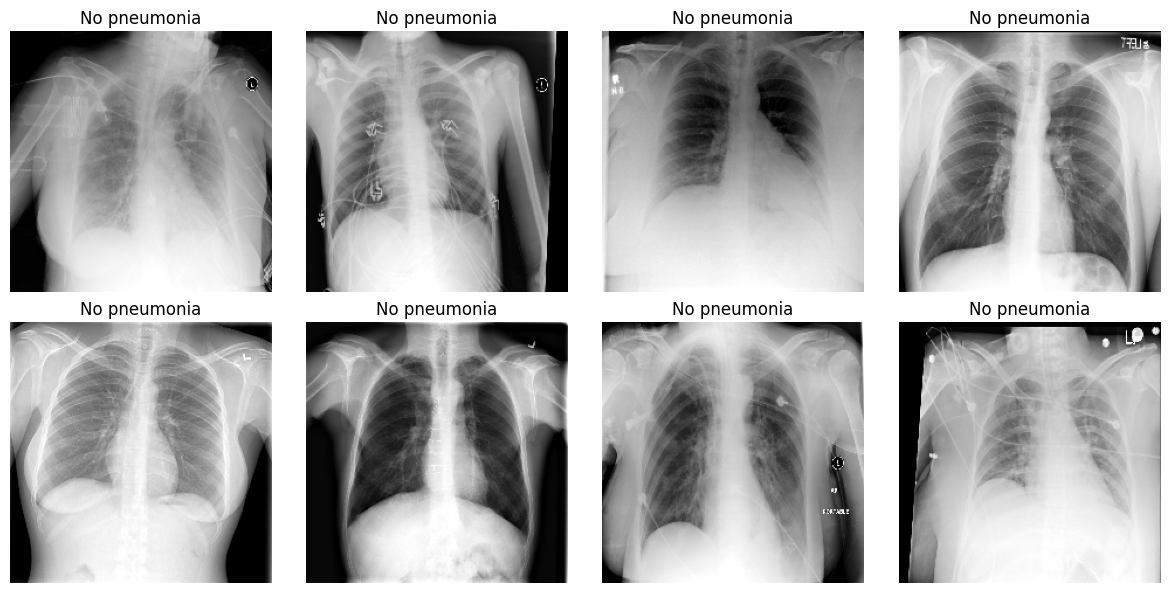

In [ ]:
# ============================================================
# 9. VISUALISE SAMPLE DICOM IMAGES
# ============================================================
plt.figure(figsize=(12, 6))

for images, labels_batch in train_ds_img.take(1):
    count = min(8, images.shape[0])
    for index in range(count):
        image = images[index].numpy()
        image = np.clip(image / 255.0, 0.0, 1.0)

        plt.subplot(2, 4, index + 1)
        plt.imshow(image)
        plt.title("Pneumonia" if int(labels_batch[index].numpy()) == 1 else "No pneumonia")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 10. CUSTOM CNN BASELINE
# ============================================================
def build_custom_cnn(input_shape=(*IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape, name="cnn_image_input")

    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.06),
    ], name="cnn_augmentation")

    x = augmentation(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prediction")(x)

    return keras.Model(inputs, outputs, name="custom_cnn_baseline")


custom_cnn_model = build_custom_cnn()
custom_cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

custom_cnn_model.summary()

Model: "custom_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_image_input (InputLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# 11. TRAIN CUSTOM CNN
# ============================================================
custom_cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        OUTPUT_DIR / "custom_cnn_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
    ),
]

history_custom_cnn = custom_cnn_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=EPOCHS_CUSTOM_CNN,
    class_weight=class_weight_dict,
    callbacks=custom_cnn_callbacks,
    verbose=1,
)

Epoch 1/8
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 2320s 2s/step - accuracy: 0.6878 - auc: 0.7559 - loss: 0.5920 - precision: 0.3943 - recall: 0.7197 - val_accuracy: 0.7717 - val_auc: 0.6919 - val_loss: 0.6516 - val_precision: 0.4310 - val_recall: 0.0416 - learning_rate: 0.0010
Epoch 2/8
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 454s 363ms/step - accuracy: 0.7127 - auc: 0.7850 - loss: 0.5624 - precision: 0.4213 - recall: 0.7363 - val_accuracy: 0.7717 - val_auc: 0.6965 - val_loss: 0.4919 - val_precision: 0.4394 - val_recall: 0.0483 - learning_rate: 0.0010
Epoch 3/8
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 445s 356ms/step - accuracy: 0.7200 - auc: 0.7942 - loss: 0.5515 - precision: 0.4294 - recall: 0.7387 - val_accuracy: 0.7954 - val_auc: 0.7757 - val_loss: 0.4622 - val_precision: 0.6233 - val_recall: 0.2313 - learning_rate: 0.0010
Epoch 4/8
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 447s 357ms/step - accuracy: 0.7263 - auc: 0.8037 - loss: 0.5407 - precision: 0.4374 - recall: 0.7503 - val_accuracy: 0.7916 - val_auc: 0.8000 - val_

In [ ]:
# ============================================================
# 12. IMAGE-ONLY EFFICIENTNETB0 MODEL
# ============================================================
def build_image_only_model(input_shape=(*IMG_SIZE, 3)):
    image_input = keras.Input(shape=input_shape, name="image_input")

    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.08),
        layers.RandomContrast(0.08),
    ], name="image_augmentation")

    x = augmentation(image_input)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="image_gap")(x)
    x = layers.Dense(128, activation="relu", name="image_dense")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction",
    )(x)

    model = keras.Model(image_input, output, name="efficientnet_image_only")
    return model, base_model


image_only_model, image_base = build_image_only_model()

image_only_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)

image_only_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnet_image_only"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_gap                       │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_dense (Dense)             │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ============================================================
# 13. TRAIN IMAGE-ONLY EFFICIENTNET
# ============================================================
image_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
    keras.callbacks.ModelCheckpoint(
        OUTPUT_DIR / "efficientnet_image_only_best.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
    ),
]

history_image = image_only_model.fit(
    train_ds_img,
    validation_data=val_ds_img,
    epochs=EPOCHS_IMAGE_ONLY,
    class_weight=class_weight_dict,
    callbacks=image_callbacks,
    verbose=1,
)

Epoch 1/10
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 442s 346ms/step - accuracy: 0.7205 - auc: 0.7983 - loss: 0.5465 - precision: 0.4316 - recall: 0.7589 - val_accuracy: 0.6548 - val_auc: 0.8350 - val_loss: 0.6551 - val_precision: 0.3859 - val_recall: 0.9002 - learning_rate: 0.0010
Epoch 2/10
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 434s 347ms/step - accuracy: 0.7310 - auc: 0.8194 - loss: 0.5216 - precision: 0.4447 - recall: 0.7793 - val_accuracy: 0.6938 - val_auc: 0.8389 - val_loss: 0.5843 - val_precision: 0.4148 - val_recall: 0.8752 - learning_rate: 0.0010
Epoch 3/10
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 433s 346ms/step - accuracy: 0.7336 - auc: 0.8252 - loss: 0.5139 - precision: 0.4477 - recall: 0.7811 - val_accuracy: 0.7770 - val_auc: 0.8365 - val_loss: 0.4459 - val_precision: 0.5036 - val_recall: 0.6988 - learning_rate: 0.0010
Epoch 4/10
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 441s 353ms/step - accuracy: 0.7364 - auc: 0.8287 - loss: 0.5104 - precision: 0.4515 - recall: 0.7909 - val_accuracy: 0.6803 - val_auc: 0.8424 

In [ ]:
# ============================================================
# 14. IMPROVED MULTIMODAL EFFICIENTNETB0 + METADATA MODEL
# ============================================================
keras.backend.clear_session()

def build_multimodal_model(metadata_dimension, input_shape=(*IMG_SIZE, 3)):
    image_input = keras.Input(shape=input_shape, name="image_input")
    metadata_input = keras.Input(shape=(metadata_dimension,), name="metadata_input")

    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.06),
        layers.RandomContrast(0.08),
        layers.RandomTranslation(0.03, 0.03),
    ], name="multimodal_augmentation")

    x = augmentation(image_input)
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="image_gap")(x)
    x = layers.BatchNormalization(name="image_bn")(x)
    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name="image_dense_1",
    )(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation="swish", name="image_dense_2")(x)
    x = layers.Dropout(0.25)(x)

    m = layers.BatchNormalization(name="metadata_bn")(metadata_input)
    m = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name="metadata_dense_1",
    )(m)
    m = layers.Dropout(0.25)(m)
    m = layers.Dense(32, activation="relu", name="metadata_dense_2")(m)

    fused = layers.Concatenate(name="image_metadata_fusion")([x, m])
    fused = layers.BatchNormalization(name="fusion_bn")(fused)
    fused = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name="fusion_dense_1",
    )(fused)
    fused = layers.Dropout(0.40)(fused)
    fused = layers.Dense(64, activation="relu", name="fusion_dense_2")(fused)
    fused = layers.Dropout(0.20)(fused)

    output = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="pneumonia_probability",
    )(fused)

    model = keras.Model(
        inputs={"image_input": image_input, "metadata_input": metadata_input},
        outputs=output,
        name="improved_multimodal_efficientnet",
    )
    return model, base_model

multimodal_model, multimodal_base = build_multimodal_model(metadata_dim)
multimodal_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=HEAD_LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ],
)
multimodal_model.summary()


Model: "improved_multimodal_efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multimodal_augment… │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ multimodal_augme… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 1280)      │      5,120 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_1       │ (None, 256)       │    327,936 │ image_bn[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_bn         │ (None, 5)         │         20 │ metadata_input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ image_dense_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_dense_1    │ (None, 64)        │        384 │ metadata_bn[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_2       │ (None, 128)       │     32,896 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ metadata_dense_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ image_dense_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_dense_2    │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_metadata_fus… │ (None, 160)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ metadata_dense_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 160)       │        640 │ image_metadata_f… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 256)       │     41,216 │ fusion_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ fusion_dense_1[0

 Total params: 4,476,376 (17.08 MB)

 Trainable params: 423,915 (1.62 MB)

 Non-trainable params: 4,052,461 (15.46 MB)

In [ ]:
# ============================================================
# 14B. HYPERPARAMETER TUNING FOR EFFICIENTNETB0 + METADATA
# ============================================================
# This section keeps the original notebook structure and searches
# a small, controlled set of multimodal configurations.
#
# Selection is based only on validation ROC-AUC. The test set is
# not used during tuning, which prevents test-data leakage.

import gc
import json

HYPERPARAMETER_TUNING_EPOCHS = 4

HYPERPARAMETER_CONFIGURATIONS = [
    {
        "name": "trial_1",
        "head_learning_rate": 1e-3,
        "fine_tune_learning_rate": 1e-5,
        "fine_tune_fraction": 0.80,
        "image_units": 128,
        "metadata_units": 32,
        "fusion_units": 128,
        "image_dropout": 0.30,
        "metadata_dropout": 0.20,
        "fusion_dropout": 0.30,
        "l2_rate": 1e-4,
    },
    {
        "name": "trial_2",
        "head_learning_rate": 3e-4,
        "fine_tune_learning_rate": 5e-6,
        "fine_tune_fraction": 0.70,
        "image_units": 256,
        "metadata_units": 64,
        "fusion_units": 256,
        "image_dropout": 0.40,
        "metadata_dropout": 0.25,
        "fusion_dropout": 0.40,
        "l2_rate": 1e-4,
    },
    {
        "name": "trial_3",
        "head_learning_rate": 1e-4,
        "fine_tune_learning_rate": 5e-6,
        "fine_tune_fraction": 0.70,
        "image_units": 256,
        "metadata_units": 32,
        "fusion_units": 128,
        "image_dropout": 0.30,
        "metadata_dropout": 0.20,
        "fusion_dropout": 0.30,
        "l2_rate": 5e-5,
    },
    {
        "name": "trial_4",
        "head_learning_rate": 5e-4,
        "fine_tune_learning_rate": 5e-6,
        "fine_tune_fraction": 0.60,
        "image_units": 256,
        "metadata_units": 64,
        "fusion_units": 128,
        "image_dropout": 0.50,
        "metadata_dropout": 0.30,
        "fusion_dropout": 0.40,
        "l2_rate": 1e-4,
    },
]


def build_tunable_multimodal_model(
    metadata_dimension,
    configuration,
    input_shape=(*IMG_SIZE, 3),
):
    image_input = keras.Input(
        shape=input_shape,
        name="image_input"
    )

    metadata_input = keras.Input(
        shape=(metadata_dimension,),
        name="metadata_input"
    )

    augmentation = keras.Sequential(
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.04),
            layers.RandomZoom(0.06),
            layers.RandomContrast(0.08),
            layers.RandomTranslation(0.03, 0.03),
        ],
        name="multimodal_augmentation",
    )

    image_features = augmentation(image_input)

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
    )
    base_model.trainable = False

    image_features = base_model(
        image_features,
        training=False
    )

    image_features = layers.GlobalAveragePooling2D(
        name="image_gap"
    )(image_features)

    image_features = layers.BatchNormalization(
        name="image_bn"
    )(image_features)

    image_features = layers.Dense(
        configuration["image_units"],
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(
            configuration["l2_rate"]
        ),
        name="image_dense_tuned",
    )(image_features)

    image_features = layers.Dropout(
        configuration["image_dropout"],
        name="image_dropout_tuned",
    )(image_features)

    metadata_features = layers.BatchNormalization(
        name="metadata_bn"
    )(metadata_input)

    metadata_features = layers.Dense(
        configuration["metadata_units"],
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(
            configuration["l2_rate"]
        ),
        name="metadata_dense_tuned",
    )(metadata_features)

    metadata_features = layers.Dropout(
        configuration["metadata_dropout"],
        name="metadata_dropout_tuned",
    )(metadata_features)

    fused_features = layers.Concatenate(
        name="image_metadata_fusion"
    )(
        [
            image_features,
            metadata_features,
        ]
    )

    fused_features = layers.BatchNormalization(
        name="fusion_bn"
    )(fused_features)

    fused_features = layers.Dense(
        configuration["fusion_units"],
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(
            configuration["l2_rate"]
        ),
        name="fusion_dense_tuned",
    )(fused_features)

    fused_features = layers.Dropout(
        configuration["fusion_dropout"],
        name="fusion_dropout_tuned",
    )(fused_features)

    output = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="pneumonia_probability",
    )(fused_features)

    model = keras.Model(
        inputs={
            "image_input": image_input,
            "metadata_input": metadata_input,
        },
        outputs=output,
        name="tunable_multimodal_efficientnet",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=configuration[
                "head_learning_rate"
            ]
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model, base_model


tuning_records = []

for trial_number, configuration in enumerate(
    HYPERPARAMETER_CONFIGURATIONS,
    start=1,
):
    print("\n" + "=" * 72)
    print(
        f"HYPERPARAMETER TRIAL "
        f"{trial_number}/"
        f"{len(HYPERPARAMETER_CONFIGURATIONS)}"
    )
    print(json.dumps(configuration, indent=2))
    print("=" * 72)

    trial_model = None
    trial_base = None

    try:
        trial_model, trial_base = (
            build_tunable_multimodal_model(
                metadata_dimension=metadata_dim,
                configuration=configuration,
            )
        )

        trial_history = trial_model.fit(
            train_ds_multi,
            validation_data=val_ds_multi,
            epochs=HYPERPARAMETER_TUNING_EPOCHS,
            class_weight=class_weight_dict,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_auc",
                    mode="max",
                    patience=2,
                    restore_best_weights=True,
                    verbose=1,
                ),
                keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    mode="min",
                    factor=0.3,
                    patience=1,
                    min_lr=1e-7,
                    verbose=1,
                ),
            ],
            verbose=1,
        )

        best_val_auc = float(
            max(trial_history.history["val_auc"])
        )

        best_val_accuracy = float(
            max(trial_history.history["val_accuracy"])
        )

        best_val_loss = float(
            min(trial_history.history["val_loss"])
        )

        epochs_completed = len(
            trial_history.history["loss"]
        )

        trial_status = "completed"
        error_message = ""

    except Exception as error:
        best_val_auc = 0.0
        best_val_accuracy = 0.0
        best_val_loss = float("inf")
        epochs_completed = 0
        trial_status = "failed"
        error_message = str(error)

        print(
            f"Trial {trial_number} failed: "
            f"{error_message}"
        )

    tuning_records.append(
        {
            "trial_number": trial_number,
            **configuration,
            "best_val_auc": best_val_auc,
            "best_val_accuracy": best_val_accuracy,
            "best_val_loss": best_val_loss,
            "epochs_completed": epochs_completed,
            "status": trial_status,
            "error_message": error_message,
        }
    )

    del trial_model
    del trial_base
    gc.collect()


hyperparameter_results_df = pd.DataFrame(
    tuning_records
)

hyperparameter_results_df.to_csv(
    OUTPUT_DIR / "hyperparameter_tuning_results.csv",
    index=False,
)

successful_trials_df = hyperparameter_results_df[
    hyperparameter_results_df["status"] == "completed"
].copy()

if successful_trials_df.empty:
    raise RuntimeError(
        "All hyperparameter tuning trials failed. "
        "Check the error messages in the tuning results."
    )

successful_trials_df = successful_trials_df.sort_values(
    by=[
        "best_val_auc",
        "best_val_accuracy",
        "best_val_loss",
    ],
    ascending=[
        False,
        False,
        True,
    ],
)

best_trial_row = successful_trials_df.iloc[0]
best_trial_number = int(
    best_trial_row["trial_number"]
)

BEST_HYPERPARAMETERS = (
    HYPERPARAMETER_CONFIGURATIONS[
        best_trial_number - 1
    ].copy()
)

print("\nBest hyperparameter trial:")
display(
    successful_trials_df.head(1)
)

print("\nSelected hyperparameters:")
print(
    json.dumps(
        BEST_HYPERPARAMETERS,
        indent=2,
    )
)

with open(
    OUTPUT_DIR / "best_hyperparameters.json",
    "w",
) as best_hyperparameter_file:
    json.dump(
        BEST_HYPERPARAMETERS,
        best_hyperparameter_file,
        indent=2,
    )


# Update the variables used by the existing training and
# fine-tuning cells that follow this section.
HEAD_LEARNING_RATE = BEST_HYPERPARAMETERS[
    "head_learning_rate"
]

FINETUNE_LEARNING_RATE = BEST_HYPERPARAMETERS[
    "fine_tune_learning_rate"
]

FINE_TUNE_AT_FRACTION = BEST_HYPERPARAMETERS[
    "fine_tune_fraction"
]


# Rebuild the final multimodal model using the selected
# hyperparameters. The original training cells below will
# train and fine-tune this selected model.
multimodal_model, multimodal_base = (
    build_tunable_multimodal_model(
        metadata_dimension=metadata_dim,
        configuration=BEST_HYPERPARAMETERS,
    )
)

multimodal_model.summary()


HYPERPARAMETER TRIAL 1/4
{
  "name": "trial_1",
  "head_learning_rate": 0.001,
  "fine_tune_learning_rate": 1e-05,
  "fine_tune_fraction": 0.8,
  "image_units": 128,
  "metadata_units": 32,
  "fusion_units": 128,
  "image_dropout": 0.3,
  "metadata_dropout": 0.2,
  "fusion_dropout": 0.3,
  "l2_rate": 0.0001
}
Epoch 1/4
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 481s 376ms/step - accuracy: 0.6967 - auc: 0.7824 - loss: 0.6127 - precision: 0.4069 - recall: 0.7563 - val_accuracy: 0.6439 - val_auc: 0.8062 - val_loss: 0.6750 - val_precision: 0.3725 - val_recall: 0.8486 - learning_rate: 0.0010
Epoch 2/4
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 445s 356ms/step - accuracy: 0.7201 - auc: 0.8105 - loss: 0.5766 - precision: 0.4329 - recall: 0.7813 - val_accuracy: 0.7339 - val_auc: 0.8310 - val_loss: 0.5786 - val_precision: 0.4495 - val_recall: 0.8070 - learning_rate: 0.0010
Epoch 3/4
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7295 - auc: 0.8166 - loss: 0.5703 - precision: 0.4439 - recall: 0.7727
Epoch 

,trial_number,name,head_learning_rate,fine_tune_learning_rate,fine_tune_fraction,image_units,metadata_units,fusion_units,image_dropout,metadata_dropout,fusion_dropout,l2_rate,best_val_auc,best_val_accuracy,best_val_loss,epochs_completed,status,error_message
0,1,trial_1,0.001,0.00001,0.8,128,32,128,0.3,0.2,0.3,0.0001,0.837883,0.74063,0.566294,4,completed,



Selected hyperparameters:
{
  "name": "trial_1",
  "head_learning_rate": 0.001,
  "fine_tune_learning_rate": 1e-05,
  "fine_tune_fraction": 0.8,
  "image_units": 128,
  "metadata_units": 32,
  "fusion_units": 128,
  "image_dropout": 0.3,
  "metadata_dropout": 0.2,
  "fusion_dropout": 0.3,
  "l2_rate": 0.0001
}


Model: "tunable_multimodal_efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multimodal_augment… │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ multimodal_augme… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 1280)      │      5,120 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_bn         │ (None, 5)         │         20 │ metadata_input[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_tuned   │ (None, 128)       │    163,968 │ image_bn[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_dense_tun… │ (None, 32)        │        192 │ metadata_bn[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout_tuned │ (None, 128)       │          0 │ image_dense_tune… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_dropout_t… │ (None, 32)        │          0 │ metadata_dense_t… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_metadata_fus… │ (None, 160)       │          0 │ image_dropout_tu… │
│ (Concatenate)       │                   │            │ metadata_dropout… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 160)       │        640 │ image_metadata_f… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_tuned  │ (None, 128)       │     20,608 │ fusion_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_tun… │ (None, 128)       │          0 │ fusion_dense_tun… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pneumonia_probabil… │ (None, 1)         │        129 │ fusion_dropout_t… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,240,248 (16.18 MB)

 Trainable params: 187,787 (733.54 KB)

 Non-trainable params: 4,052,461 (15.46 MB)

In [ ]:
# ============================================================
# 15. TRAIN IMPROVED MULTIMODAL CLASSIFIER HEAD
# ============================================================
multimodal_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5,
        min_delta=0.001, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.3, patience=2,
        min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / "improved_multimodal_head_best.keras"),
        monitor="val_auc", mode="max", save_best_only=True, verbose=1
    ),
]

history_multi_head = multimodal_model.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=EPOCHS_MULTIMODAL_HEAD,
    class_weight=class_weight_dict,
    callbacks=multimodal_callbacks,
    verbose=1,
)


Epoch 1/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.6879 - auc: 0.7650 - loss: 0.6417 - precision: 0.4016 - recall: 0.7302
Epoch 1: val_auc improved from None to 0.82116, saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_head_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_head_best.keras
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 469s 366ms/step - accuracy: 0.7029 - auc: 0.7790 - loss: 0.6177 - precision: 0.4113 - recall: 0.7392 - val_accuracy: 0.7283 - val_auc: 0.8212 - val_loss: 0.5815 - val_precision: 0.4436 - val_recall: 0.8120 - learning_rate: 0.0010
Epoch 2/20
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.7247 - auc: 0.8098 - loss: 0.5816 - precision: 0.4419 - recall: 0.7767
Epoch 2: val_auc improved from 0.82116 to 0.82435, saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_head_best.keras

Epoch 2: finished

In [ ]:
# ============================================================
# 16. FINE-TUNE LAST 30% OF EFFICIENTNET
# ============================================================
history_multi_finetune = None

if RUN_FINE_TUNING:
    multimodal_base.trainable = True
    fine_tune_start = int(len(multimodal_base.layers) * FINE_TUNE_AT_FRACTION)

    for layer in multimodal_base.layers[:fine_tune_start]:
        layer.trainable = False

    for layer in multimodal_base.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    multimodal_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINETUNE_LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    fine_tune_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=5,
            min_delta=0.001, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=2,
            min_lr=1e-7, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(OUTPUT_DIR / "improved_multimodal_finetuned_best.keras"),
            monitor="val_auc", mode="max", save_best_only=True, verbose=1
        ),
    ]

    history_multi_finetune = multimodal_model.fit(
        train_ds_multi,
        validation_data=val_ds_multi,
        epochs=EPOCHS_MULTIMODAL_FINETUNE,
        class_weight=class_weight_dict,
        callbacks=fine_tune_callbacks,
        verbose=1,
    )
else:
    print("Fine-tuning skipped.")


Epoch 1/15
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7357 - auc: 0.8293 - loss: 0.5534 - precision: 0.4536 - recall: 0.7819
Epoch 1: val_auc improved from None to 0.84573, saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_finetuned_best.keras
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 480s 373ms/step - accuracy: 0.7441 - auc: 0.8374 - loss: 0.5408 - precision: 0.4608 - recall: 0.7975 - val_accuracy: 0.7099 - val_auc: 0.8457 - val_loss: 0.5967 - val_precision: 0.4282 - val_recall: 0.8586 - learning_rate: 1.0000e-05
Epoch 2/15
1251/1251 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7477 - auc: 0.8408 - loss: 0.5393 - precision: 0.4693 - recall: 0.7994
Epoch 2: val_auc improved from 0.84573 to 0.84858, saving model to /content/drive/MyDrive/rsna_pneumonia_outputs_improved/improved_multimodal_finetuned_best.keras

In [ ]:
# ============================================================
# 17. EVALUATION FUNCTIONS
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

def get_labels_and_probabilities(model, dataset):
    true_labels = []
    probabilities = []
    for inputs, labels_batch in dataset:
        predictions = model.predict(inputs, verbose=0).reshape(-1)
        probabilities.extend(predictions.tolist())
        true_labels.extend(labels_batch.numpy().reshape(-1).tolist())
    return np.asarray(true_labels, dtype=int), np.asarray(probabilities, dtype=float)


def evaluate_model(model, dataset, model_name, threshold=0.5):
    y_true, y_probability = get_labels_and_probabilities(model, dataset)
    y_prediction = (y_probability >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_prediction)
    precision = precision_score(y_true, y_prediction, zero_division=0)
    recall = recall_score(y_true, y_prediction, zero_division=0)
    f1 = f1_score(y_true, y_prediction, zero_division=0)

    matrix = confusion_matrix(y_true, y_prediction, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    specificity = tn / max(tn + fp, 1)

    fpr, tpr, _ = roc_curve(y_true, y_probability)
    roc_auc = auc(fpr, tpr)

    print(f"\n===== {model_name}: Test Results =====")
    print(classification_report(
        y_true, y_prediction,
        labels=[0, 1],
        target_names=["No pneumonia", "Pneumonia"],
        zero_division=0,
    ))
    print("Confusion matrix:\n", matrix)
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 score:    {f1:.4f}")
    print(f"ROC-AUC:     {roc_auc:.4f}")

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["No Pneumonia", "Pneumonia"],
    )
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
    }, (fpr, tpr)


Selected validation threshold: 0.69
Validation accuracy: 0.8265
Validation F1: 0.5949

===== Custom CNN: Test Results =====
              precision    recall  f1-score   support

No pneumonia       0.92      0.61      0.73      3101
   Pneumonia       0.37      0.81      0.51       902

    accuracy                           0.65      4003
   macro avg       0.65      0.71      0.62      4003
weighted avg       0.79      0.65      0.68      4003

Confusion matrix:
 [[1877 1224]
 [ 171  731]]
Accuracy:    0.6515
Precision:   0.3739
Recall:      0.8104
Specificity: 0.6053
F1 score:    0.5117
ROC-AUC:     0.8011


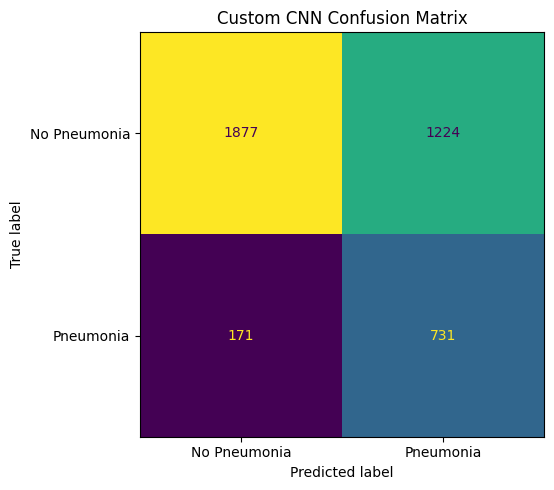


===== EfficientNetB0 image-only: Test Results =====
              precision    recall  f1-score   support

No pneumonia       0.92      0.73      0.81      3101
   Pneumonia       0.46      0.79      0.58       902

    accuracy                           0.74      4003
   macro avg       0.69      0.76      0.70      4003
weighted avg       0.82      0.74      0.76      4003

Confusion matrix:
 [[2263  838]
 [ 193  709]]
Accuracy:    0.7424
Precision:   0.4583
Recall:      0.7860
Specificity: 0.7298
F1 score:    0.5790
ROC-AUC:     0.8351


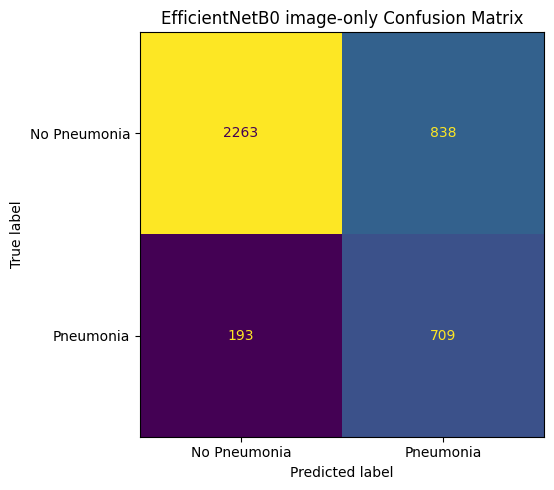


===== Improved EfficientNetB0 + metadata: Test Results =====
              precision    recall  f1-score   support

No pneumonia       0.87      0.89      0.88      3101
   Pneumonia       0.59      0.55      0.57       902

    accuracy                           0.81      4003
   macro avg       0.73      0.72      0.72      4003
weighted avg       0.81      0.81      0.81      4003

Confusion matrix:
 [[2752  349]
 [ 405  497]]
Accuracy:    0.8116
Precision:   0.5875
Recall:      0.5510
Specificity: 0.8875
F1 score:    0.5686
ROC-AUC:     0.8454


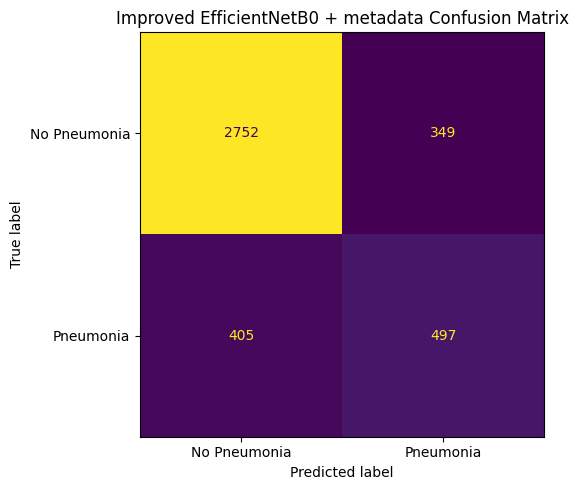

,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-Score,ROC-AUC
Model,,,,,,
Custom CNN,0.6515,0.3739,0.8104,0.6053,0.5117,0.8011
EfficientNetB0 image-only,0.7424,0.4583,0.7860,0.7298,0.5790,0.8351
Improved EfficientNetB0 + metadata,0.8116,0.5875,0.5510,0.8875,0.5686,0.8454


Saved comparison results: /content/drive/MyDrive/rsna_pneumonia_outputs_improved/model_comparison_results.csv


In [ ]:
# ============================================================
# 18. VALIDATION-BASED THRESHOLD SELECTION AND FINAL EVALUATION
# ============================================================
y_val_true, y_val_probability = get_labels_and_probabilities(
    multimodal_model, val_ds_multi
)

best_threshold = 0.50
best_validation_accuracy = -1.0
best_validation_f1 = -1.0

for threshold in np.arange(0.30, 0.701, 0.01):
    y_val_pred = (y_val_probability >= threshold).astype(int)
    current_accuracy = accuracy_score(y_val_true, y_val_pred)
    current_f1 = f1_score(y_val_true, y_val_pred, zero_division=0)

    if (current_accuracy, current_f1) > (best_validation_accuracy, best_validation_f1):
        best_validation_accuracy = current_accuracy
        best_validation_f1 = current_f1
        best_threshold = float(threshold)

print("Selected validation threshold:", round(best_threshold, 2))
print("Validation accuracy:", round(best_validation_accuracy, 4))
print("Validation F1:", round(best_validation_f1, 4))

custom_cnn_results, custom_cnn_roc = evaluate_model(
    custom_cnn_model, test_ds_cnn, "Custom CNN"
)
image_results, image_roc = evaluate_model(
    image_only_model, test_ds_img, "EfficientNetB0 image-only"
)
multimodal_results, multimodal_roc = evaluate_model(
    multimodal_model,
    test_ds_multi,
    "Improved EfficientNetB0 + metadata",
    threshold=best_threshold,
)

comparison_df = pd.DataFrame([
    custom_cnn_results,
    image_results,
    multimodal_results,
]).set_index("Model")

display(comparison_df.round(4))
comparison_path = OUTPUT_DIR / "model_comparison_results.csv"
comparison_df.to_csv(comparison_path)
print("Saved comparison results:", comparison_path)


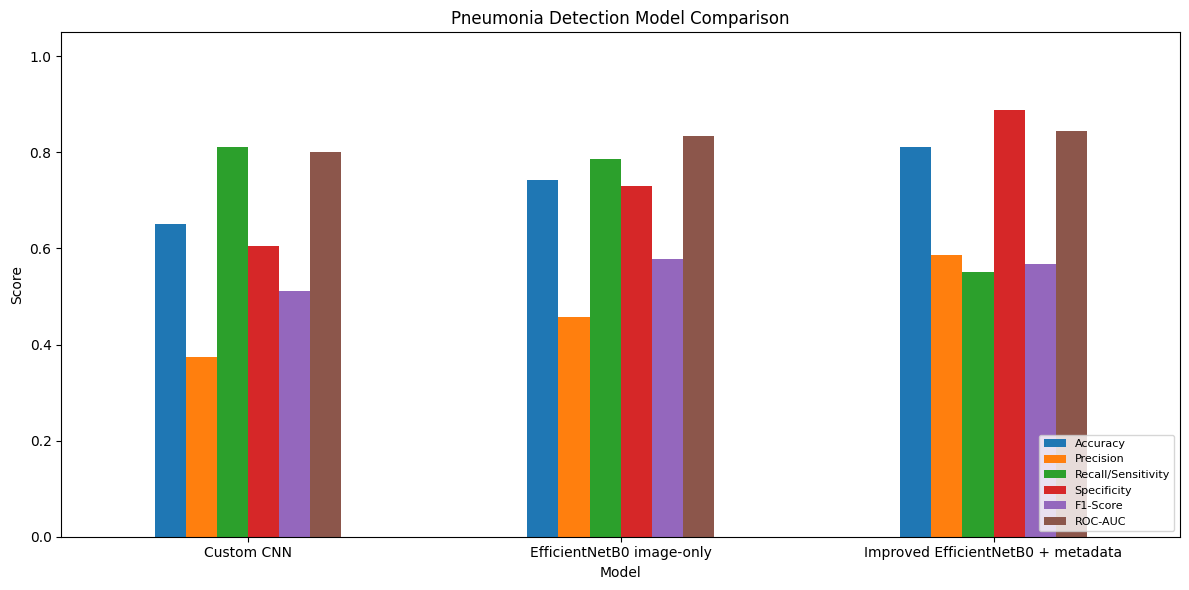

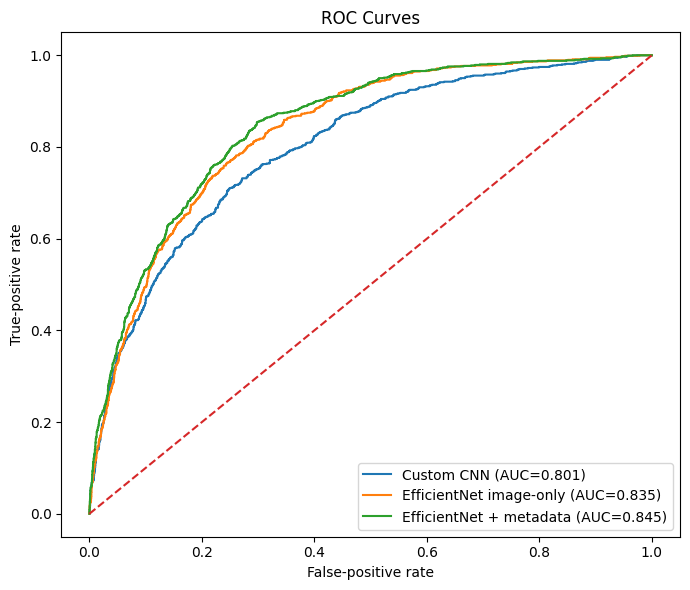

In [ ]:
# ============================================================
# 19. PLOT MODEL COMPARISON AND ROC CURVES
# ============================================================
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "F1-Score",
    "ROC-AUC",
]

comparison_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6),
    rot=0,
)
plt.title("Pneumonia Detection Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.plot(custom_cnn_roc[0], custom_cnn_roc[1], label=f"Custom CNN (AUC={custom_cnn_results['ROC-AUC']:.3f})")
plt.plot(image_roc[0], image_roc[1], label=f"EfficientNet image-only (AUC={image_results['ROC-AUC']:.3f})")
plt.plot(multimodal_roc[0], multimodal_roc[1], label=f"EfficientNet + metadata (AUC={multimodal_results['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 20. SAVE MODELS AND METADATA PREPROCESSOR
# ============================================================
import joblib

custom_cnn_model.save(OUTPUT_DIR / "final_custom_cnn.keras")
image_only_model.save(OUTPUT_DIR / "final_efficientnet_image_only.keras")
multimodal_model.save(OUTPUT_DIR / "final_multimodal_efficientnet.keras")
joblib.dump(
    metadata_preprocessor,
    OUTPUT_DIR / "metadata_preprocessor.joblib",
)

print("Saved all final models and the metadata preprocessor to:")
print(OUTPUT_DIR)

Saved all final models and the metadata preprocessor to:
/content/drive/MyDrive/rsna_pneumonia_outputs_improved


In [ ]:
# ============================================================
# 21. SINGLE-DICOM MULTIMODAL PREDICTION
# ============================================================
def predict_single_dicom(dicom_path, threshold=0.5):
    dicom_path = str(dicom_path)

    if not os.path.isfile(dicom_path):
        raise FileNotFoundError(f"DICOM file not found: {dicom_path}")

    metadata = extract_dicom_metadata(dicom_path)
    metadata_frame = pd.DataFrame([metadata])
    metadata_vector = metadata_preprocessor.transform(
        metadata_frame[metadata_columns]
    ).astype(np.float32)

    image = read_dicom_image_py(dicom_path)
    model_image = efficientnet_preprocess(
        np.expand_dims(image, axis=0)
    )

    probability = float(
        multimodal_model.predict(
            {
                "image_input": model_image,
                "metadata_input": metadata_vector,
            },
            verbose=0,
        )[0, 0]
    )

    prediction = (
        "PNEUMONIA"
        if probability >= threshold
        else "NO PNEUMONIA"
    )

    display_image = np.clip(image / 255.0, 0.0, 1.0)
    plt.figure(figsize=(5, 5))
    plt.imshow(display_image)
    plt.title(
        f"{prediction}\nPneumonia probability: {probability:.3f}"
    )
    plt.axis("off")
    plt.show()

    print("Extracted metadata:", metadata)
    return {
        "prediction": prediction,
        "pneumonia_probability": probability,
        "metadata": metadata,
    }


# Example after training:
# result = predict_single_dicom(test_paths[0])
# result